In [1]:
!pip install spacy
!pip install nltk
!pip install seaborn
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 61.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
df = pd.read_csv(
    "job_descriptions.csv",
    engine="python",
    encoding="latin-1",
    on_bad_lines="skip"
)

print("Initial Rows:", len(df))
df.head()


Initial Rows: 1404618


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801.0,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340.0,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525.0,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896.0,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944.0,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [29]:
df = df[['Job Title', 'Job Description', 'skills', 'Responsibilities']]


df = df.dropna()

print("After Removing Nulls:", len(df))


After Removing Nulls: 1404617


In [30]:
df['combined_text'] = (
    df['Job Description'].astype(str) + " " +
    df['skills'].astype(str) + " " +
    df['Responsibilities'].astype(str)
)


In [31]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['combined_text'].apply(clean_text)


In [32]:
df = df.drop_duplicates(subset='clean_text')
df.reset_index(drop=True, inplace=True)

print("After Removing Duplicates:", len(df))


After Removing Duplicates: 376


In [34]:
sample_size = min(50000, len(df))

df = df.sample(n=sample_size, random_state=42)
df.reset_index(drop=True, inplace=True)

print("Using Sample Size:", len(df))


Using Sample Size: 376


In [13]:
target_vector = tfidf_matrix[-1]
job_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(job_vectors, target_vector)

df['similarity_score'] = similarity_scores.flatten()


In [35]:
print("=== Resume Screening & Job Matching System ===")
target_job = input("Enter the job description for matching:\n")

target_clean = clean_text(target_job)


=== Resume Screening & Job Matching System ===
Enter the job description for matching:
Looking for a Data Scientist with experience in Python, machine learning, data preprocessing, SQL, statistics, model building, feature engineering, and deployment using cloud platforms. Candidate should have strong analytical skills and experience with deep learning frameworks.


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

all_text = df['clean_text'].tolist()
all_text.append(target_clean)

tfidf_matrix = vectorizer.fit_transform(all_text)


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

target_vector = tfidf_matrix[-1]
job_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(job_vectors, target_vector)

df['similarity_score'] = similarity_scores.flatten()


In [39]:
df_sorted = df.sort_values(by='similarity_score', ascending=False)

df_sorted[['Job Title','similarity_score']].head(10)


,Job Title,similarity_score
72,Data Scientist,0.474368
165,Data Analyst,0.354106
364,Technical Writer,0.320272
320,Data Analyst,0.228062
251,Data Engineer,0.224107
184,Software Architect,0.218263
180,Marketing Analyst,0.217450
176,Systems Engineer,0.216188
361,Data Analyst,0.211110
360,Business Analyst,0.205861


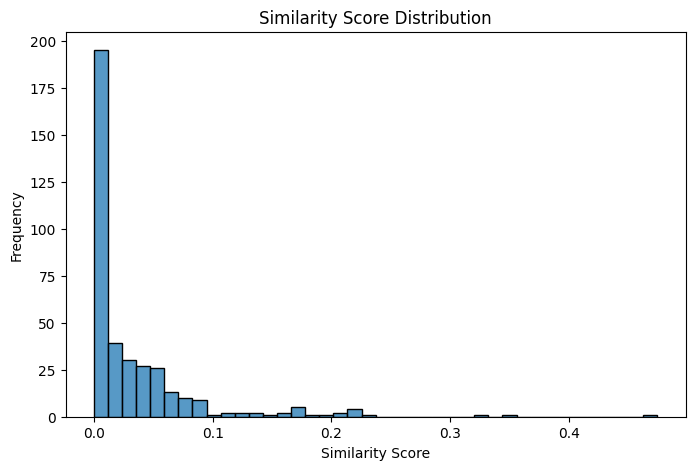

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['similarity_score'], bins=40)
plt.title("Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()


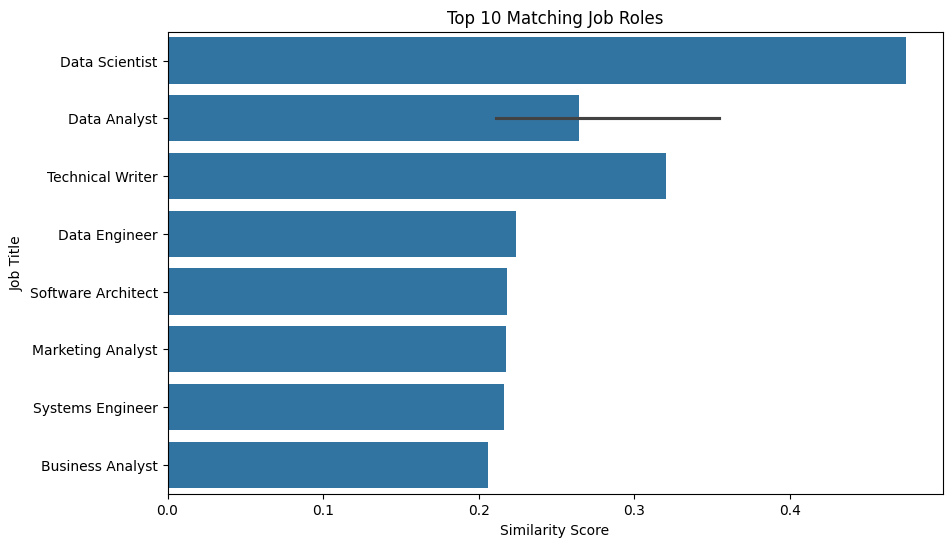

In [42]:
top_10 = df_sorted.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_10['similarity_score'],
    y=top_10['Job Title']
)

plt.title("Top 10 Matching Job Roles")
plt.xlabel("Similarity Score")
plt.ylabel("Job Title")
plt.show()


In [43]:
def extract_skill_set(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return set(text.split())

target_skill_set = extract_skill_set(target_job)

def find_skill_gap(skill_text):
    job_set = extract_skill_set(skill_text)
    missing = target_skill_set - job_set
    return list(missing)[:8]

df_sorted['missing_skills'] = df_sorted['skills'].apply(find_skill_gap)

df_sorted[['Job Title','similarity_score','missing_skills']].head(5)


,Job Title,similarity_score,missing_skills
72,Data Scientist,0.474368,"[statistics, using, platforms, deployment, wit..."
165,Data Analyst,0.354106,"[statistics, using, platforms, deployment, dee..."
364,Technical Writer,0.320272,"[statistics, using, data, platforms, deploymen..."
320,Data Analyst,0.228062,"[statistics, using, platforms, learning, deplo..."
251,Data Engineer,0.224107,"[statistics, using, platforms, learning, deplo..."


In [44]:
for i in range(3):
    print("Rank:", i+1)
    print("Job Title:", df_sorted.iloc[i]['Job Title'])
    print("Similarity Score:", round(df_sorted.iloc[i]['similarity_score'], 3))
    print("Missing Skills:", df_sorted.iloc[i]['missing_skills'])
    print("-"*50)


Rank: 1
Job Title: Data Scientist
Similarity Score: 0.474
Missing Skills: ['statistics', 'using', 'platforms', 'deployment', 'with', 'sql', 'feature', 'candidate']
--------------------------------------------------
Rank: 2
Job Title: Data Analyst
Similarity Score: 0.354
Missing Skills: ['statistics', 'using', 'platforms', 'deployment', 'deep', 'with', 'sql', 'model']
--------------------------------------------------
Rank: 3
Job Title: Technical Writer
Similarity Score: 0.32
Missing Skills: ['statistics', 'using', 'data', 'platforms', 'deployment', 'preprocessing', 'deep', 'with']
--------------------------------------------------


In [45]:
df_sorted.to_csv("ranked_jobs.csv", index=False)
print("Ranked results saved successfully.")


Ranked results saved successfully.
